### Métricas de clasificación


MÉTRICAS POR MODELO:

               Precision  Recall  F1-score   AUC
Carpeta                                         
informesGPT35       0.61    0.58      0.59  0.75
informesDS          0.45    0.40      0.42  0.64
informesGPT4        0.56    0.56      0.56  0.73
informesGPT4o       0.56    0.75      0.63  0.80


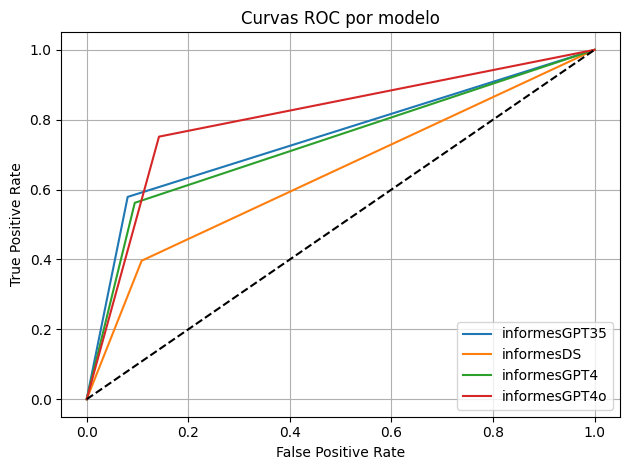

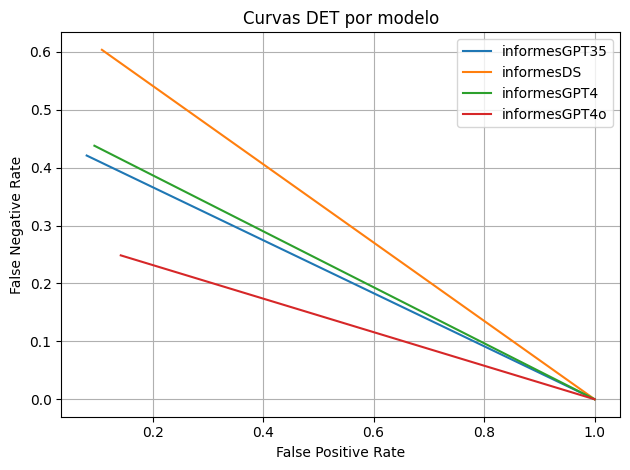

In [1]:
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    det_curve
)
import pandas as pd

def limpiar_json(contratos):
    for contrato, secciones in contratos.items():
        for seccion in secciones:
            if "label_expected" not in seccion and "label_gpt" in seccion:
                del seccion["label_gpt"]
    return contratos

carpetas = ["informesGPT35", "informesDS", "informesGPT4", "informesGPT4o"]  # ajusta según tus carpetas reales
categorias = ["legalidad", "abusividad", "áreas de riesgo", "vaguedades", "lagunas"]

# Guardar métricas y curvas por carpeta
metricas_df = []
curvas_roc = {}
curvas_det = {}

for carpeta in carpetas:
    y_true_total = []
    y_pred_total = []
    metricas = {"Precision": [], "Recall": [], "F1-score": [], "AUC": []}

    if not os.path.isdir(carpeta):
        print(f"Carpeta no encontrada: {carpeta}")
        continue

    for archivo in os.listdir(carpeta):
        if archivo.endswith(".json"):
            with open(os.path.join(carpeta, archivo), "r", encoding="utf-8") as file:
                contratos = json.load(file)

            contratos = limpiar_json(contratos)

            y_true = []
            y_pred = []

            for contrato, secciones in contratos.items():
                for seccion in secciones:
                    label_gpt = seccion.get("label_gpt", {})
                    label_expected = seccion.get("label_expected", {})

                    for categoria in categorias:
                        valor_real = label_expected.get(categoria, "")
                        valor_predicho = label_gpt.get(categoria, "")

                        if categoria == "legalidad":
                            y_true.append(1 if valor_real == "L" else 0)
                            y_pred.append(1 if valor_predicho == "L" else 0)
                        else:
                            y_true.append(1 if valor_real == "S" else 0)
                            y_pred.append(1 if valor_predicho == "S" else 0)

            if y_true and y_pred:
                metricas["Precision"].append(precision_score(y_true, y_pred, zero_division=0))
                metricas["Recall"].append(recall_score(y_true, y_pred, zero_division=0))
                metricas["F1-score"].append(f1_score(y_true, y_pred, zero_division=0))
                metricas["AUC"].append(roc_auc_score(y_true, y_pred))
                y_true_total.extend(y_true)
                y_pred_total.extend(y_pred)

    # Si hay datos en la carpeta
    if y_true_total and y_pred_total:
        avg_metrics = {metrica: sum(valores) / len(valores) if valores else 0 for metrica, valores in metricas.items()}
        avg_metrics["Carpeta"] = carpeta
        metricas_df.append(avg_metrics)

        # Curvas ROC y DET
        fpr, tpr, _ = roc_curve(y_true_total, y_pred_total)
        fpr_det, fnr_det, _ = det_curve(y_true_total, y_pred_total)

        curvas_roc[carpeta] = (fpr, tpr)
        curvas_det[carpeta] = (fpr_det, fnr_det)

# Mostrar tabla de métricas
df = pd.DataFrame(metricas_df)
df.set_index("Carpeta", inplace=True)
print("\nMÉTRICAS POR MODELO:\n")
print(df.round(2))

# Curva ROC
plt.figure()
for carpeta, (fpr, tpr) in curvas_roc.items():
    auc = roc_auc_score(
        [1 if t >= 0.5 else 0 for t in tpr], [1 if f >= 0.5 else 0 for f in fpr]
    )  # solo para mostrar el texto
    plt.plot(fpr, tpr, label=f"{carpeta}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC por modelo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Curva DET
plt.figure()
for carpeta, (fpr_det, fnr_det) in curvas_det.items():
    plt.plot(fpr_det, fnr_det, label=f"{carpeta}")
plt.xlabel("False Positive Rate")
plt.ylabel("False Negative Rate")
plt.title("Curvas DET por modelo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Estabilidad, readability, self-consistency, perplexity

In [7]:
import os
import textstat
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stopwords_es = stopwords.words('spanish')

# Rutas
base_path = "informes/"
carpetas = ["informesDS", "informesGPT4", "informesGPT4o", "informesGPT35"]

# Modelo de GPT-2 para perplexity
model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)


def calcular_perplejidad(texto):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
    loss = outputs.loss.item()
    return np.exp(loss)


def calcular_coherencia_semantica(textos):
    vectorizer = TfidfVectorizer(stop_words=stopwords_es)
    tfidf_matrix = vectorizer.fit_transform(textos)
    similitudes = cosine_similarity(tfidf_matrix)
    indices = np.triu_indices_from(similitudes, k=1)
    return np.mean(similitudes[indices]) if len(similitudes[indices]) > 0 else 0


# Resultados
resultados = []

for carpeta in carpetas:
    ruta = os.path.join(base_path, carpeta)
    readability_scores = []
    perplexity_scores = []
    textos = []

    for archivo in os.listdir(ruta):
        if archivo.endswith(".txt"):
            with open(os.path.join(ruta, archivo), "r", encoding="utf-8") as file:
                texto = file.read()
                textos.append(texto)
            readability_scores.append(textstat.flesch_reading_ease(texto))
            perplexity_scores.append(calcular_perplejidad(texto))

    mean_readability = np.mean(readability_scores) if readability_scores else 0
    mean_perplexity = np.mean(perplexity_scores) if perplexity_scores else 0
    mean_coherence = calcular_coherencia_semantica(textos) if textos else 0

    resultados.append({
        "carpeta": carpeta,
        "readability": mean_readability,
        "perplexity": mean_perplexity,
        "coherencia": mean_coherence
    })

# Gráfico
etiquetas = [r["carpeta"] for r in resultados]
readability = [r["readability"] for r in resultados]
perplexity = [r["perplexity"] for r in resultados]
coherencia = [r["coherencia"] for r in resultados]

x = np.arange(len(etiquetas))
width = 0.25

print("\nResultados por carpeta:")
print("{:<15} {:>12} {:>12} {:>12}".format("Carpeta", "Readability", "Perplexity", "Coherencia"))
print("-" * 55)
for r in resultados:
    print("{:<15} {:>12.2f} {:>12.2f} {:>12.2f}".format(
        r["carpeta"], r["readability"], r["perplexity"], r["coherencia"]
    ))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\grill\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Resultados por carpeta:
Carpeta          Readability   Perplexity   Coherencia
-------------------------------------------------------
informesDS             34.29        30.99         0.38
informesGPT4           34.36        23.30         0.38
informesGPT4o          32.46        36.15         0.53
informesGPT35          32.77        19.26         0.49


### Readability (Legibilidad)

El índice de legibilidad se basa en la fórmula **Flesch Reading Ease**, que evalúa cuán fácil es leer un texto. La escala es la siguiente:

| **Puntuación** | **Nivel de dificultad**       | **Ejemplo**                    |
|----------------|-------------------------------|--------------------------------|
| 90 - 100       | Muy fácil                     | Nivel de primaria              |
| 60 - 70        | Fácil                         | Nivel de secundaria            |
| 30 - 50        | Difícil                       | Nivel universitario            |
| 0 - 30         | Muy difícil                   | Documentos legales o técnicos  |

---

### Perplexity (Perplejidad)

La perplejidad mide cuán predecible es un texto para un modelo de lenguaje. Cuanto menor sea la perplejidad, más comprensible y fluido resulta el texto. La interpretación es la siguiente:

| **Perplejidad** | **Interpretación**                                                     |
|-----------------|------------------------------------------------------------------------|
| 1 - 10         | Texto muy predecible (frases simples o repetitivas)                    |
| 10 - 50        | Texto natural y bien estructurado                                      |
| 50 - 100       | Texto algo complejo o con errores                                      |
| 100+           | Texto muy confuso o desordenado                                          |

---

### Semantic Coherence (Coherencia Semántica)

La coherencia semántica mide el grado de relación semántica entre diferentes textos utilizando la similitud de coseno entre sus representaciones TF-IDF. Este valor refleja cuán relacionados están los conceptos y las ideas presentadas en los documentos analizados.

| **Puntuación** | **Nivel de Coherencia**       | **Interpretación**                                            |
|------------------|------------------------------|---------------------------------------------------------------|
| 0.0 - 0.3        | Baja                          | Los textos son incoherentes y no presentan temas relacionados. |
| 0.3 - 0.6        | Moderada                      | Hay cierta relación entre los textos, pero no es muy fuerte.  |
| 0.6 - 1.0        | Alta                          | Los textos son altamente coherentes y bien relacionados.       |

---



### Estabilidad y self consistency por clausulas


Resultados por carpeta:
Carpeta          Estabilidad     Self-Consistency
--------------------------------------------------
informesDS            0.3835               0.4677
informesGPT4          0.3977               0.5946
informesGPT4o         0.2809               0.6648
informesGPT35         0.4805               0.7118


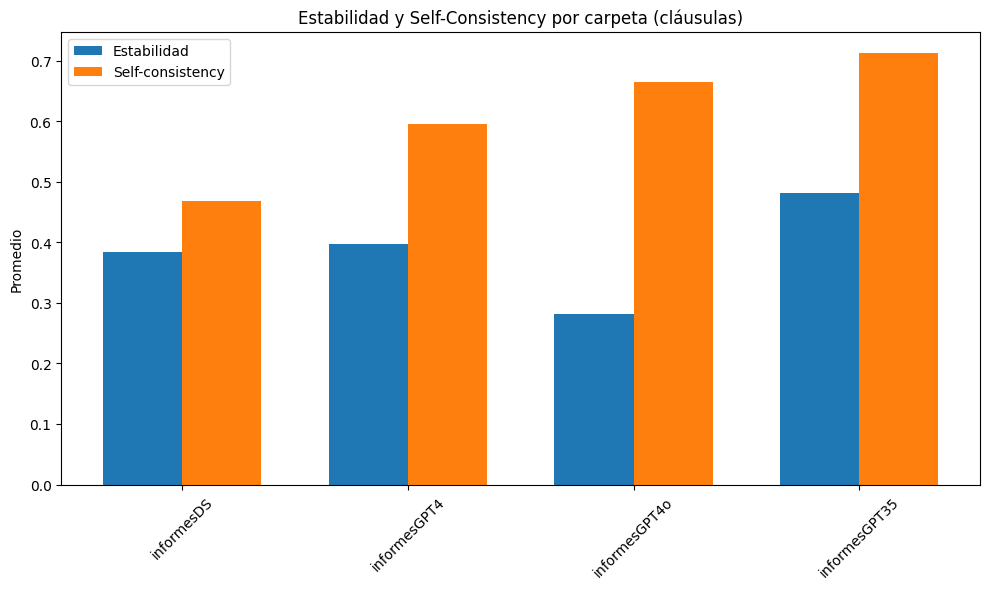

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import itertools

# Lista de carpetas a analizar
base_path = "informes/"
carpetas = ["informesDS", "informesGPT4", "informesGPT4o", "informesGPT35"]

def leer_informes_por_region(ruta):
    regiones = {}
    for archivo in os.listdir(ruta):
        if archivo.endswith(".txt"):
            partes = archivo.split("_")
            region = "_".join(partes[:-1])
            with open(os.path.join(ruta, archivo), "r", encoding="utf-8") as f:
                clausulas = f.read().split("###")
                clausulas = [c.strip() for c in clausulas if c.strip()]
                if region not in regiones:
                    regiones[region] = []
                regiones[region].append(clausulas)
    return regiones

def calcular_estabilidad_self_consistency(region, clausulas_por_region):
    num_clausulas = max(len(c) for c in itertools.chain(*clausulas_por_region))
    estabilidad_clausula = []
    consistencia_clausula = []

    for i in range(num_clausulas):
        clausulas_actuales = [c[i] for c in clausulas_por_region if len(c) > i]
        if len(clausulas_actuales) < 2:
            continue
        num_combinaciones = len(clausulas_actuales) * (len(clausulas_actuales) - 1) // 2
        if num_combinaciones < 9:
            continue

        vectorizer = TfidfVectorizer().fit_transform(clausulas_actuales)
        matriz_similitud = cosine_similarity(vectorizer)
        distancias = 1 - matriz_similitud[np.triu_indices(len(clausulas_actuales), k=1)]

        max_dist = np.max(distancias) if len(distancias) > 0 else 1
        estabilidad = 1 - (np.mean(distancias) / max_dist if max_dist > 0 else 0)

        contradicciones = sum(1 for d in distancias if d > 0.5)
        consistencia = 1 - (contradicciones / len(distancias))

        estabilidad_clausula.append(estabilidad)
        consistencia_clausula.append(consistencia)

    return np.mean(estabilidad_clausula), np.mean(consistencia_clausula)

# Procesar cada carpeta
resultados = []

for carpeta in carpetas:
    ruta = os.path.join(base_path, carpeta)
    regiones = leer_informes_por_region(ruta)
    estabilidad_global, consistencia_global = [], []

    for region, clausulas in regiones.items():
        estabilidad, consistencia = calcular_estabilidad_self_consistency(region, clausulas)
        estabilidad_global.append(estabilidad)
        consistencia_global.append(consistencia)

    resultados.append({
        "carpeta": carpeta,
        "estabilidad": np.mean(estabilidad_global),
        "consistencia": np.mean(consistencia_global)
    })

# Mostrar resultados con print antes del gráfico
print("\nResultados por carpeta:")
print("{:<15} {:>12} {:>20}".format("Carpeta", "Estabilidad", "Self-Consistency"))
print("-" * 50)
for r in resultados:
    print("{:<15} {:>12.4f} {:>20.4f}".format(
        r["carpeta"], r["estabilidad"], r["consistencia"]
    ))

# Graficar
etiquetas = [r["carpeta"] for r in resultados]
estabilidad_vals = [r["estabilidad"] for r in resultados]
consistencia_vals = [r["consistencia"] for r in resultados]

x = np.arange(len(etiquetas))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, estabilidad_vals, width, label="Estabilidad")
plt.bar(x + width/2, consistencia_vals, width, label="Self-consistency")
plt.xticks(x, etiquetas, rotation=45)
plt.ylabel("Promedio")
plt.title("Estabilidad y Self-Consistency por carpeta (cláusulas)")
plt.legend()
plt.tight_layout()
plt.show()


##### Estas métricas perjudican al modelo GPT4o
ya que es el único que contesta a todas las cláusulas y por lo tanto tiene más probabilidades de equivocarse

### Estabilidad y self consistency por contrato completo


Resultados por carpeta:
Carpeta          Estabilidad     Self-Consistency
--------------------------------------------------
informesDS            0.4228               0.4048
informesGPT4          0.3735               0.5095
informesGPT4o         0.3655               0.9571
informesGPT35         0.4581               0.7524


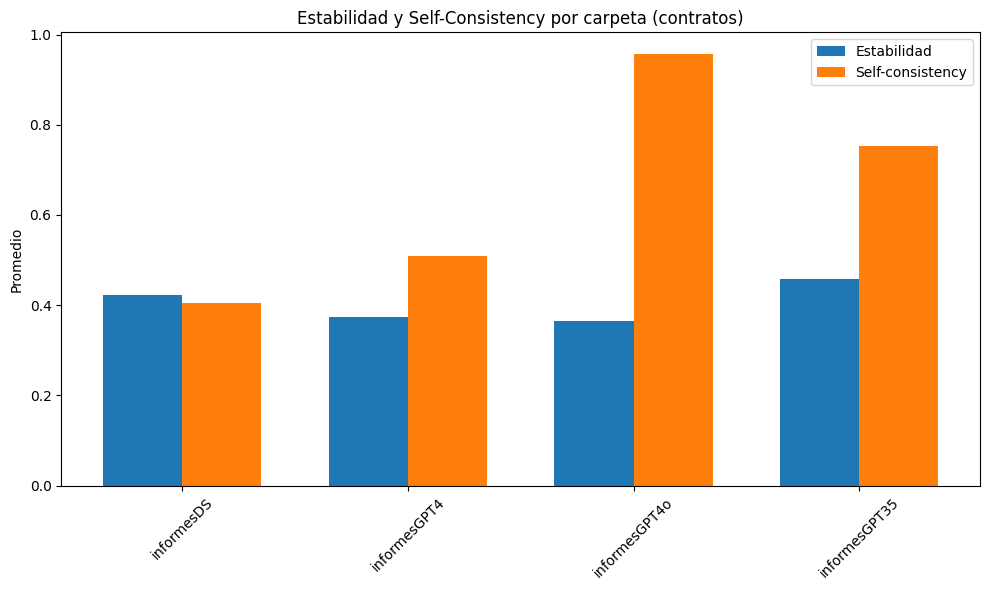

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Lista de carpetas a analizar
base_path = "informes/"
carpetas = ["informesDS", "informesGPT4", "informesGPT4o", "informesGPT35"]

def leer_contratos_por_region(ruta):
    regiones = {}
    for archivo in os.listdir(ruta):
        if archivo.endswith(".txt"):  
            partes = archivo.split("_")
            region = "_".join(partes[:-1])  # Extraer el nombre de la región
            with open(os.path.join(ruta, archivo), "r", encoding="utf-8") as f:
                contrato = f.read().strip()
                if region not in regiones:
                    regiones[region] = []
                regiones[region].append(contrato)
    return regiones

def calcular_estabilidad_self_consistency(region, contratos):
    if len(contratos) < 2:
        return 1.0, 1.0  # Si solo hay un contrato, se considera perfecto

    vectorizer = TfidfVectorizer().fit_transform(contratos)
    matriz_similitud = cosine_similarity(vectorizer)

    distancias = 1 - matriz_similitud[np.triu_indices(len(contratos), k=1)]
    max_dist = np.max(distancias) if len(distancias) > 0 else 1
    estabilidad = 1 - (np.mean(distancias) / max_dist if max_dist > 0 else 0)

    contradicciones = sum(1 for d in distancias if d > 0.3)  # Umbral de contradicción
    consistencia = 1 - (contradicciones / len(distancias))

    return estabilidad, consistencia

# Recolectar resultados
resultados = []

for carpeta in carpetas:
    ruta = os.path.join(base_path, carpeta)
    regiones = leer_contratos_por_region(ruta)
    estabilidad_global, consistencia_global = [], []

    for region, contratos in regiones.items():
        estabilidad, consistencia = calcular_estabilidad_self_consistency(region, contratos)
        estabilidad_global.append(estabilidad)
        consistencia_global.append(consistencia)

    resultados.append({
        "carpeta": carpeta,
        "estabilidad": np.mean(estabilidad_global),
        "consistencia": np.mean(consistencia_global)
    })

# Mostrar resultados
print("\nResultados por carpeta:")
print("{:<15} {:>12} {:>20}".format("Carpeta", "Estabilidad", "Self-Consistency"))
print("-" * 50)
for r in resultados:
    print("{:<15} {:>12.4f} {:>20.4f}".format(
        r["carpeta"], r["estabilidad"], r["consistencia"]
    ))

# Graficar resultados
etiquetas = [r["carpeta"] for r in resultados]
estabilidad_vals = [r["estabilidad"] for r in resultados]
consistencia_vals = [r["consistencia"] for r in resultados]

x = np.arange(len(etiquetas))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, estabilidad_vals, width, label="Estabilidad")
plt.bar(x + width/2, consistencia_vals, width, label="Self-consistency")
plt.xticks(x, etiquetas, rotation=45)
plt.ylabel("Promedio")
plt.title("Estabilidad y Self-Consistency por carpeta (contratos)")
plt.legend()
plt.tight_layout()
plt.show()


#### Métricas de redacción alternativa
#### similaridad métrica a añadir



Similaridad base vs alternativo por carpeta:
Carpeta                      Similitud
----------------------------------------
informesDS_prompt               0.6800
informesGPT4_prompt             0.6670
informesGPT4o_prompt            0.7683
informesGPT35_prompt            0.7207


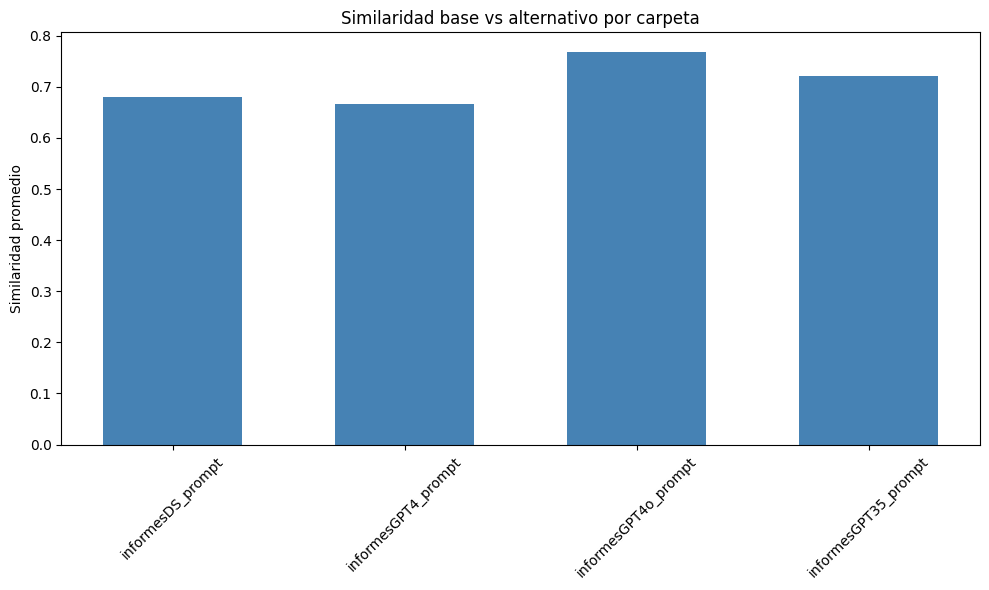

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Carpeta raíz y subcarpetas a analizar
base_path = "informes_cambio_prompt/"
carpetas = ["informesDS_prompt", "informesGPT4_prompt", "informesGPT4o_prompt", "informesGPT35_prompt"]

def leer_contratos_por_region(ruta):
    regiones = {}
    for archivo in os.listdir(ruta):
        if ("base" in archivo or "alternativo" in archivo):
            partes = archivo.split("_")
            region = "_".join(partes[1:-2])  # Región está entre medio
            tipo = partes[-2]  # 'base' o 'alternativo'

            with open(os.path.join(ruta, archivo), "r", encoding="utf-8") as f:
                contrato = f.read().strip()
                if region not in regiones:
                    regiones[region] = {}
                regiones[region][tipo] = contrato
    return regiones

def calcular_similaridad_base_alternativo(region, base_text, alternativo_text):
    vectorizer = TfidfVectorizer().fit_transform([base_text, alternativo_text])
    matriz_similitud = cosine_similarity(vectorizer)
    return matriz_similitud[0, 1]

# Lista para recolectar resultados por carpeta
resultados = []

for carpeta in carpetas:
    ruta = os.path.join(base_path, carpeta)
    regiones = leer_contratos_por_region(ruta)
    similaridades = []

    for region, textos in regiones.items():
        if "base" in textos and "alternativo" in textos:
            sim = calcular_similaridad_base_alternativo(region, textos["base"], textos["alternativo"])
            similaridades.append(sim)
        else:
            print(f"[!] Región incompleta en {carpeta}: {region}")

    media = np.mean(similaridades) if similaridades else 0
    resultados.append({
        "carpeta": carpeta,
        "similaridad": media
    })

# Mostrar resultados
print("\nSimilaridad base vs alternativo por carpeta:")
print("{:<25} {:>12}".format("Carpeta", "Similitud"))
print("-" * 40)
for r in resultados:
    print("{:<25} {:>12.4f}".format(r["carpeta"], r["similaridad"]))

# Gráfico
etiquetas = [r["carpeta"] for r in resultados]
valores = [r["similaridad"] for r in resultados]

x = np.arange(len(etiquetas))
width = 0.6

plt.figure(figsize=(10, 6))
plt.bar(x, valores, width, color='steelblue')
plt.xticks(x, etiquetas, rotation=45)
plt.ylabel("Similaridad promedio")
plt.title("Similaridad base vs alternativo por carpeta")
plt.tight_layout()
plt.show()


### PRUEBA PARA LA LIBRERÍA DE MÉTRICAS!


MÉTRICAS POR MODELO:

                        Precision  Recall  F1-score   AUC
Carpeta                                                  
informes/informesGPT35       0.61    0.58      0.59  0.75
informes/informesDS          0.45    0.40      0.42  0.64
informes/informesGPT4        0.56    0.56      0.56  0.73
informes/informesGPT4o       0.56    0.75      0.63  0.80


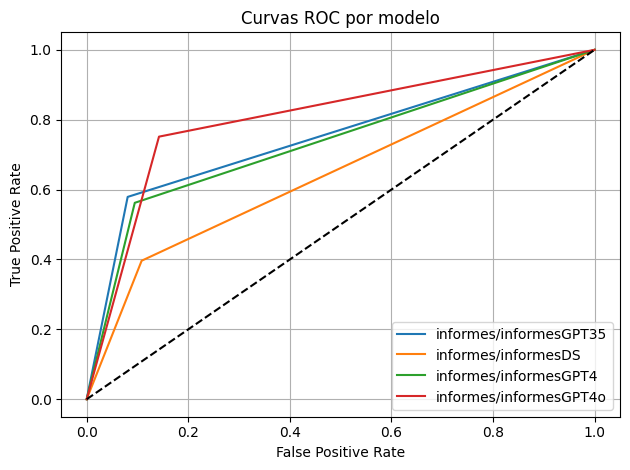

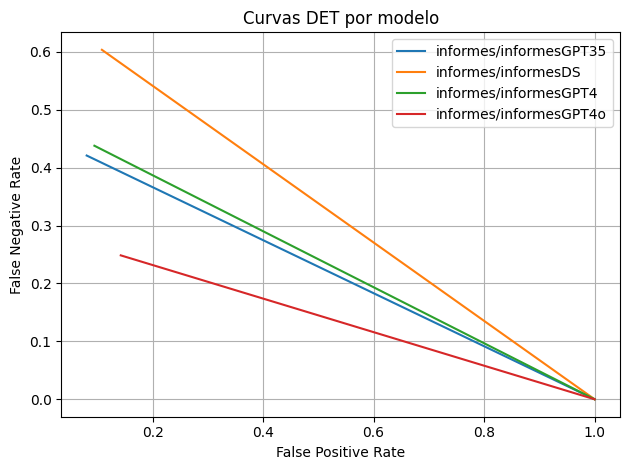

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\grill\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



MÉTRICAS DE CALIDAD DE TEXTO POR MODELO:

                        Readability  Perplexity  Semantic Coherence
Carpeta                                                            
informes/informesGPT35        32.77       19.26                0.49
informes/informesDS           34.29       30.99                0.38
informes/informesGPT4         34.36       23.30                0.38
informes/informesGPT4o        32.46       36.15                0.53


In [1]:
import sys
sys.path.append("C:/Users/grill/Documents/Trabajo")

from Libreria.metrics import classification_metrix, quality_metrics_from_folders


carpetas = ["informes/informesGPT35", "informes/informesDS", "informes/informesGPT4", "informes/informesGPT4o"]
df_metricas = classification_metrix(carpetas)


df_calidad = quality_metrics_from_folders(carpetas)

